# Challenge 3: Inteligencia Geo-Temporal y de Redes
## Optimización de Activos Críticos — TechLogistics S.A.

**Curso:** Fundamentos de Datos — Maestría en Ciencia de los Datos, Universidad EAFIT
**Docente:** Jorge Iván Padilla-Buriticá | **Periodo:** 2026-1

**Integrantes:**
- Juan Esteban García — 1020222158
- Manuela Castaño — 1011510403
- Juan Felipe Restrepo — 1027740136

---

### Contexto del negocio

TechLogistics S.A. es una empresa ficticia que administra dos redes de sensores georreferenciadas: una red agroindustrial en el oriente antioqueño (cadena de frío / monitoreo de cultivos) y una red eléctrica nacional (subestaciones y nodos de carga). Ambas redes generan datos en el tiempo, pero hasta ahora se han analizado por separado. El objetivo de este taller es integrar tres dimensiones de análisis — **series de tiempo**, **procesamiento de señales** y **grafos/geoespacial** — para responder tres preguntas de la junta directiva:

1. ¿Cómo se propaga el ruido dentro de la red de sensores?
2. ¿Dónde se localizan los puntos críticos (calor / baja biomasa) en el territorio?
3. ¿Cuál es el pronóstico de carga de la red eléctrica y qué tan crítico es cada nodo?

Este notebook sigue la metodología **CRISP-DM**: cada fase corresponde a una etapa del ciclo (comprensión de datos, procesamiento, modelado de redes y modelado predictivo con toma de decisiones). Cada bloque de código está precedido por una celda de texto que explica **qué se hace y por qué**, de manera que el flujo de trabajo pueda ser auditado por cualquier persona del equipo.

### Datos utilizados

Los datos fuente están en `data/input/`:
- `agro_clean.csv` / `agro_noise.csv`: 2000 lecturas de la red de sensores agroindustriales (variables `Agro_1` a `Agro_10`, coordenadas y topología `Source_Node`/`Target_Node`).
- `ener_clean.csv` / `ener_noise.csv`: 2000 lecturas de la red eléctrica (variables `Ener_1` a `Ener_10`, coordenadas y topología `Source_Node`/`Target_Node`).

Las versiones `*_noise` contienen ruido blanco gaussiano aditivo (AWGN) inyectado sobre las señales, y *jitter* (error aleatorio) sobre las coordenadas GPS, simulando fallas de precisión de los sensores. El detalle de cada variable está documentado en `documentacion/Lecture_03_dictionary.pdf`.

## 0. Configuración inicial

Antes de empezar el análisis se importan las librerías necesarias para cada dimensión del taller: `pandas`/`numpy` para el manejo de datos tabulares, `plotly` para la visualización geoespacial interactiva, `scipy`/`statsmodels` para series de tiempo y procesamiento de señales, `networkx` para el análisis de grafos y `scikit-learn` para las pruebas de agrupamiento espacial (DBSCAN). También se define una carpeta `figures/` donde se guardan en formato PNG las figuras que luego se citan como evidencia en el informe técnico ejecutivo (PDF), y una carpeta `data/output/` para los productos intermedios (series filtradas, tablas de centralidad, etc.).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy import signal, stats
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.statespace.sarimax import SARIMAX

import networkx as nx

# Rutas del proyecto (el notebook vive en notebooks/)
DATA_DIR = os.path.join("..", "data", "input")
OUT_DIR = os.path.join("..", "data", "output")
FIG_DIR = os.path.join("..", "figures")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
np.random.seed(42)

PALETTE = dict(primary="#2E5F8A", accent="#C96E27", ok="#2E7D5B", warn="#B3392C", neutral="#6B7280")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10.5,
})

print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


In [2]:
# Carga de los 4 archivos fuente
agro_clean = pd.read_csv(os.path.join(DATA_DIR, "agro_clean.csv"))
agro_noise = pd.read_csv(os.path.join(DATA_DIR, "agro_noise.csv"))
ener_clean = pd.read_csv(os.path.join(DATA_DIR, "ener_clean.csv"))
ener_noise = pd.read_csv(os.path.join(DATA_DIR, "ener_noise.csv"))

for name, df in [("agro_clean", agro_clean), ("agro_noise", agro_noise),
                  ("ener_clean", ener_clean), ("ener_noise", ener_noise)]:
    print(f"{name:12s} -> {df.shape[0]} filas x {df.shape[1]} columnas")

agro_clean.head(3)

agro_clean   -> 2000 filas x 14 columnas
agro_noise   -> 2000 filas x 14 columnas
ener_clean   -> 2000 filas x 14 columnas
ener_noise   -> 2000 filas x 14 columnas


,Agro_1,Agro_2,Agro_3,Agro_4,Agro_5,Agro_6,Agro_7,Agro_8,Agro_9,Agro_10,Latitude,Longitude,Source_Node,Target_Node
0,60.248357,47.797447,65.395554,0.000000,0.478718,2.498349,10.000000,6.432151,1.258741,4.663639,6.20368,-75.400366,4,17
1,60.080940,48.076702,66.143237,25.002075,0.467100,2.473166,10.006672,6.469450,1.106051,4.683748,6.28231,-75.474525,14,21
2,60.623974,48.002378,66.342755,49.941596,0.449259,2.464547,10.013349,6.440262,1.183610,8.353141,6.16519,-75.476937,14,22


**Nota metodológica sobre la dimensión temporal.** Ninguno de los cuatro archivos trae una columna de fecha/hora explícita: cada fila representa una lectura consecutiva de la red de sensores, por lo que a lo largo del taller se usa el **índice de fila como eje temporal** (un "paso" = una lectura). Esto es razonable porque el diccionario de datos describe estas tablas como series muestreadas de forma regular, y es la misma convención que se usa en el resto del curso cuando se trabaja con `statsmodels` sobre un `DataFrame` sin índice de fechas.

También se verificó que las columnas `Source_Node` y `Target_Node` son **idénticas fila a fila entre las versiones `clean` y `noise`** (se confirmó con `DataFrame.equals`). Esto es relevante para el "Reto del Taller" planteado en el diccionario de datos (¿se puede recuperar la topología del grafo desde datos ruidosos?): la respuesta, verificada empíricamente en la Tarea 5, es que **sí**, porque el ruido (AWGN) y el *jitter* GPS afectan únicamente a las señales continuas y a las coordenadas, **no** a los identificadores de nodo que definen la topología.

# Fase 1 — Data Understanding y Geo-Visualización

## Tarea 1: Exploración Geo-Temporal

**Qué se hace y por qué.** Se carga `agro_clean.csv` y se construye un mapa interactivo (`scatter_mapbox` de Plotly Express) que ubica cada lectura de sensor sobre el oriente antioqueño. El **color** de cada punto representa el NDVI (`Agro_5`, un índice de biomasa/verdor: entre más alto, más vegetación sana) y el **tamaño** representa la humedad (`Agro_1`). Con esto la junta directiva puede ver de un vistazo en qué zonas del territorio la vegetación está más estresada y si eso coincide con alguna condición de humedad particular. Se usa el estilo de mapa `open-street-map`, que no requiere token de Mapbox.

In [3]:
fig_map1 = px.scatter_mapbox(
    agro_clean,
    lat="Latitude", lon="Longitude",
    color="Agro_5", size="Agro_1",
    color_continuous_scale="RdYlGn",
    size_max=14, zoom=9.3, height=560,
    hover_data={"Agro_5": ":.2f", "Agro_1": ":.1f", "Source_Node": True, "Target_Node": True},
    labels={"Agro_5": "NDVI", "Agro_1": "Humedad (%)"},
    title="Red de sensores agroindustriales — Oriente Antioqueño (color = NDVI, tamaño = Humedad)",
)
fig_map1.update_layout(mapbox_style="open-street-map", margin=dict(l=0, r=0, t=45, b=0))
fig_map1.write_image(os.path.join(FIG_DIR, "fig01_mapa_ndvi_humedad.png"), scale=2)
fig_map1.show()

**¿Existe un patrón espacial (clustering) donde la biomasa sea consistentemente baja?**

Para no basar la respuesta solo en la impresión visual del mapa, se aplica una prueba estadística estándar de patrones espaciales de puntos: la **razón del vecino más cercano** (similar al índice de Clark–Evans). La lógica es la siguiente:

1. Se define "NDVI bajo" como las lecturas por debajo del percentil 25 de `Agro_5`.
2. Se calcula la distancia promedio de cada punto de NDVI bajo a su vecino más cercano (`cKDTree` de `scipy`).
3. Se compara esa distancia promedio contra la distancia promedio esperada si esos mismos puntos estuvieran ubicados **al azar** dentro de la misma región (se simulan 200 muestras aleatorias del mismo tamaño tomadas del total de coordenadas observadas).
4. Se calcula la razón `R = distancia_observada / distancia_aleatoria_promedio`. Si `R < 1` los puntos de NDVI bajo están más juntos entre sí de lo esperado por azar (evidencia de agrupamiento/clustering); si `R ≈ 1`, la distribución es indistinguible de un patrón aleatorio; si `R > 1`, los puntos están más dispersos de lo normal.

Como complemento visual se corre también `DBSCAN` sobre esas mismas coordenadas, que agrupa puntos por densidad y permite ver en el mapa si hay bolsones geográficos concretos de baja biomasa.

In [4]:
def nn_mean_dist(coords):
    tree = cKDTree(coords)
    d, _ = tree.query(coords, k=2)  # k=2 porque el vecino mas cercano de un punto es el mismo punto (k=1)
    return d[:, 1].mean()

q25_ndvi = agro_clean["Agro_5"].quantile(0.25)
low_ndvi = agro_clean[agro_clean["Agro_5"] <= q25_ndvi].copy()
coords_low = low_ndvi[["Latitude", "Longitude"]].values

nn_low = nn_mean_dist(coords_low)

rng = np.random.default_rng(42)
nn_random = []
for _ in range(200):
    idx = rng.choice(len(agro_clean), size=len(low_ndvi), replace=False)
    coords_r = agro_clean.iloc[idx][["Latitude", "Longitude"]].values
    nn_random.append(nn_mean_dist(coords_r))
nn_random = np.array(nn_random)

R = nn_low / nn_random.mean()
z = (nn_low - nn_random.mean()) / nn_random.std()

print(f"Umbral de NDVI bajo (percentil 25): {q25_ndvi:.3f}")
print(f"Puntos con NDVI bajo: {len(low_ndvi)} de {len(agro_clean)}")
print(f"Distancia promedio al vecino mas cercano (NDVI bajo):   {nn_low:.5f} grados")
print(f"Distancia promedio al vecino mas cercano (aleatorio):   {nn_random.mean():.5f} +/- {nn_random.std():.5f} grados")
print(f"Razon R = {R:.3f}   |   z-score = {z:.3f}")
if abs(z) < 1.96:
    print("-> No hay evidencia estadisticamente significativa (95%) de agrupamiento espacial.")
else:
    print("-> Evidencia estadisticamente significativa de agrupamiento espacial (p<0.05).")

Umbral de NDVI bajo (percentil 25): 0.857
Puntos con NDVI bajo: 500 de 2000
Distancia promedio al vecino mas cercano (NDVI bajo):   0.00456 grados
Distancia promedio al vecino mas cercano (aleatorio):   0.00459 +/- 0.00011 grados
Razon R = 0.994   |   z-score = -0.272
-> No hay evidencia estadisticamente significativa (95%) de agrupamiento espacial.


In [5]:
db = DBSCAN(eps=0.01, min_samples=5).fit(coords_low)
low_ndvi["cluster"] = db.labels_
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
frac_sin_grupo = (db.labels_ == -1).mean()
print(f"DBSCAN (eps=0.01 grados ~ 1.1 km, min_samples=5): {n_clusters} agrupaciones detectadas")
print(f"Fraccion de puntos de NDVI bajo que NO quedan en ninguna agrupacion densa: {frac_sin_grupo:.1%}")

low_ndvi["cluster_label"] = np.where(low_ndvi["cluster"] == -1, "sin agrupar", "agrupado (DBSCAN)")
fig_clusters = px.scatter_mapbox(
    low_ndvi, lat="Latitude", lon="Longitude", color="cluster_label",
    color_discrete_map={"sin agrupar": "#B0B0B0", "agrupado (DBSCAN)": "#B3392C"},
    zoom=9.3, height=520, title="Lecturas de NDVI bajo (percentil 25): agrupadas vs. dispersas (DBSCAN)",
)
fig_clusters.update_layout(mapbox_style="open-street-map", margin=dict(l=0, r=0, t=45, b=0))
fig_clusters.write_image(os.path.join(FIG_DIR, "fig02_clusters_ndvi_bajo.png"), scale=2)
fig_clusters.show()

DBSCAN (eps=0.01 grados ~ 1.1 km, min_samples=5): 37 agrupaciones detectadas
Fraccion de puntos de NDVI bajo que NO quedan en ninguna agrupacion densa: 21.2%


**Análisis.** La razón de vecino más cercano da `R ≈ 1` con un `z-score` dentro del rango de no significancia (`|z| < 1.96`, es decir, no se puede rechazar la hipótesis de aleatoriedad espacial completa con 95% de confianza). En otras palabras: **con la evidencia disponible en este conjunto de datos, no se encuentra un patrón espacial estadísticamente significativo donde la biomasa sea consistentemente baja**; los puntos de NDVI bajo aparecen distribuidos por el territorio de forma parecida a lo que se esperaría si el bajo NDVI ocurriera al azar y no por una causa geográfica común (por ejemplo, una ladera o una zona sin riego).

Esto tiene sentido con la forma en que están construidas las coordenadas en este dataset: cada lectura trae una coordenada prácticamente única (no hay un grupo fijo de "sensores" con ubicación fija que se repita en el tiempo), así que el ruido de muestreo domina sobre cualquier patrón geográfico real. DBSCAN sí encuentra algunas agrupaciones pequeñas en el mapa, pero esto es esperable incluso en datos completamente aleatorios (un proceso de puntos aleatorio uniforme casi nunca se ve "parejo": siempre hay zonas con más densidad de puntos por azar). Por eso la prueba formal (vecino más cercano) es la que se usa como evidencia principal, y el mapa de DBSCAN se deja como apoyo visual exploratorio.

**Recomendación práctica:** antes de invertir en infraestructura dirigida a "zonas de baja biomasa", TechLogistics debería instalar sensores con ubicación fija y repetible en el tiempo (en este dataset la posición cambia en cada lectura), de forma que sea posible diferenciar una verdadera señal geográfica de la variabilidad natural de un proceso aleatorio.

## Tarea 2: Análisis de Estacionariedad y Windowing

**Qué se hace y por qué.** Una serie es **estacionaria** cuando su media y su varianza no cambian con el tiempo. Esto es importante porque casi todos los modelos clásicos de series de tiempo (ARIMA, correlaciones, pruebas de causalidad) asumen estacionariedad; aplicarlos sobre una serie con tendencia lleva a conclusiones erróneas (esto se retoma como pregunta de validación en el informe técnico). La prueba **ADF (Augmented Dickey-Fuller)** contrasta la hipótesis nula de que la serie tiene una raíz unitaria (no estacionaria) contra la alternativa de que es estacionaria. Se aplica a las 10 variables de energía (`Ener_1` a `Ener_10`) del archivo `ener_clean.csv`, y para las que resultan no estacionarias se prueba si diferenciarlas una vez (I(1) → I(0)) alcanza a corregir el problema.

In [6]:
def adf_report(series, name):
    stat, p, used_lag, nobs, crit, *_ = adfuller(series.dropna(), autolag="AIC")
    return {"variable": name, "adf_stat": stat, "p_value": p, "lags": used_lag,
            "n_obs": nobs, "estacionaria_5%": p < 0.05}

rows = []
non_stationary = []
for i in range(1, 11):
    col = f"Ener_{i}"
    r = adf_report(ener_clean[col], col)
    rows.append(r)
    if not r["estacionaria_5%"]:
        non_stationary.append(col)

adf_table = pd.DataFrame(rows).set_index("variable")
adf_table

,adf_stat,p_value,lags,n_obs,estacionaria_5%
variable,,,,,
Ener_1,-1.866891e+00,0.347793,26,1973,False
Ener_2,-1.479135e+00,0.543807,14,1985,False
Ener_3,-1.928441e+00,0.318802,26,1973,False
Ener_4,-1.337539e+10,0.000000,12,1987,True
Ener_5,-3.477077e-01,0.918470,0,1999,False
Ener_6,9.526991e-01,0.993741,0,1999,False
Ener_7,-4.244451e-01,0.905937,26,1973,False
Ener_8,-4.603634e+01,0.000000,0,1999,True
Ener_9,-4.535819e+01,0.000000,0,1999,True


La tabla anterior muestra, para cada variable, el estadístico ADF, el p-value y si se puede considerar estacionaria al 5% de significancia. Esto coincide en general con lo que anticipa el diccionario de datos: `Ener_1–3` (mercado spot) y `Ener_5–7` (factores macro: costo de gas y emisiones) tienden a no ser estacionarias en nivel, mientras que `Ener_8–10` (calidad de potencia: frecuencia, voltaje, factor de potencia) sí lo son, por tratarse de variables físicas reguladas dentro de rangos estrechos. `Ener_4` (generación eólica) tiene una dinámica cíclica compleja; el ADF la marca como estacionaria en varianza/nivel, pero **no** se debe interpretar esto como ausencia de estructura temporal: en la Tarea 3 se usa análisis espectral (más apropiado que el ADF) para describir su comportamiento cíclico.

**Diferenciación I(1).** Para cada serie no estacionaria se aplica una diferencia de primer orden (`y_t - y_{t-1}`) y se repite el ADF. Esto es exactamente lo que exige el checklist de entrega antes de ajustar cualquier modelo ARIMA: **no se debe modelar en niveles una serie con tendencia**, hay que llevarla primero a estacionariedad.

In [7]:
diff_rows = []
for col in non_stationary:
    diff = ener_clean[col].diff().dropna()
    r = adf_report(diff, f"{col} (diferenciada)")
    diff_rows.append(r)

diff_table = pd.DataFrame(diff_rows).set_index("variable")
print("Series no estacionarias en nivel:", non_stationary)
diff_table

Series no estacionarias en nivel: ['Ener_1', 'Ener_2', 'Ener_3', 'Ener_5', 'Ener_6', 'Ener_7']


,adf_stat,p_value,lags,n_obs,estacionaria_5%
variable,,,,,
Ener_1 (diferenciada),-5.018335,2.041162e-05,26,1972,True
Ener_2 (diferenciada),-18.107409,2.543239e-30,13,1985,True
Ener_3 (diferenciada),-5.071523,1.599008e-05,26,1972,True
Ener_5 (diferenciada),-43.656308,0.000000e+00,0,1998,True
Ener_6 (diferenciada),-30.635512,0.000000e+00,1,1997,True
Ener_7 (diferenciada),-14.768128,2.345220e-27,26,1972,True


Como se ve en la tabla, **todas** las series que no eran estacionarias en nivel sí lo son después de una sola diferencia (p-value prácticamente 0 en todos los casos). Esto confirma que son series integradas de orden 1, es decir **I(1)**, tal como lo anuncia el diccionario de datos para el NDVI/biomasa y para el costo de gas/emisiones. En la Fase 4 (modelo ARIMAX) se usa `d=1` para `Ener_1` por este mismo motivo.

**Ventana móvil (windowing).** Para las series no estacionarias se calcula media y varianza móvil con una ventana de 50 registros. Si la media móvil sube o baja de forma sostenida (no es plana), es señal de tendencia; si además la varianza móvil también cambia con el tiempo, es señal adicional de no estacionariedad en varianza.

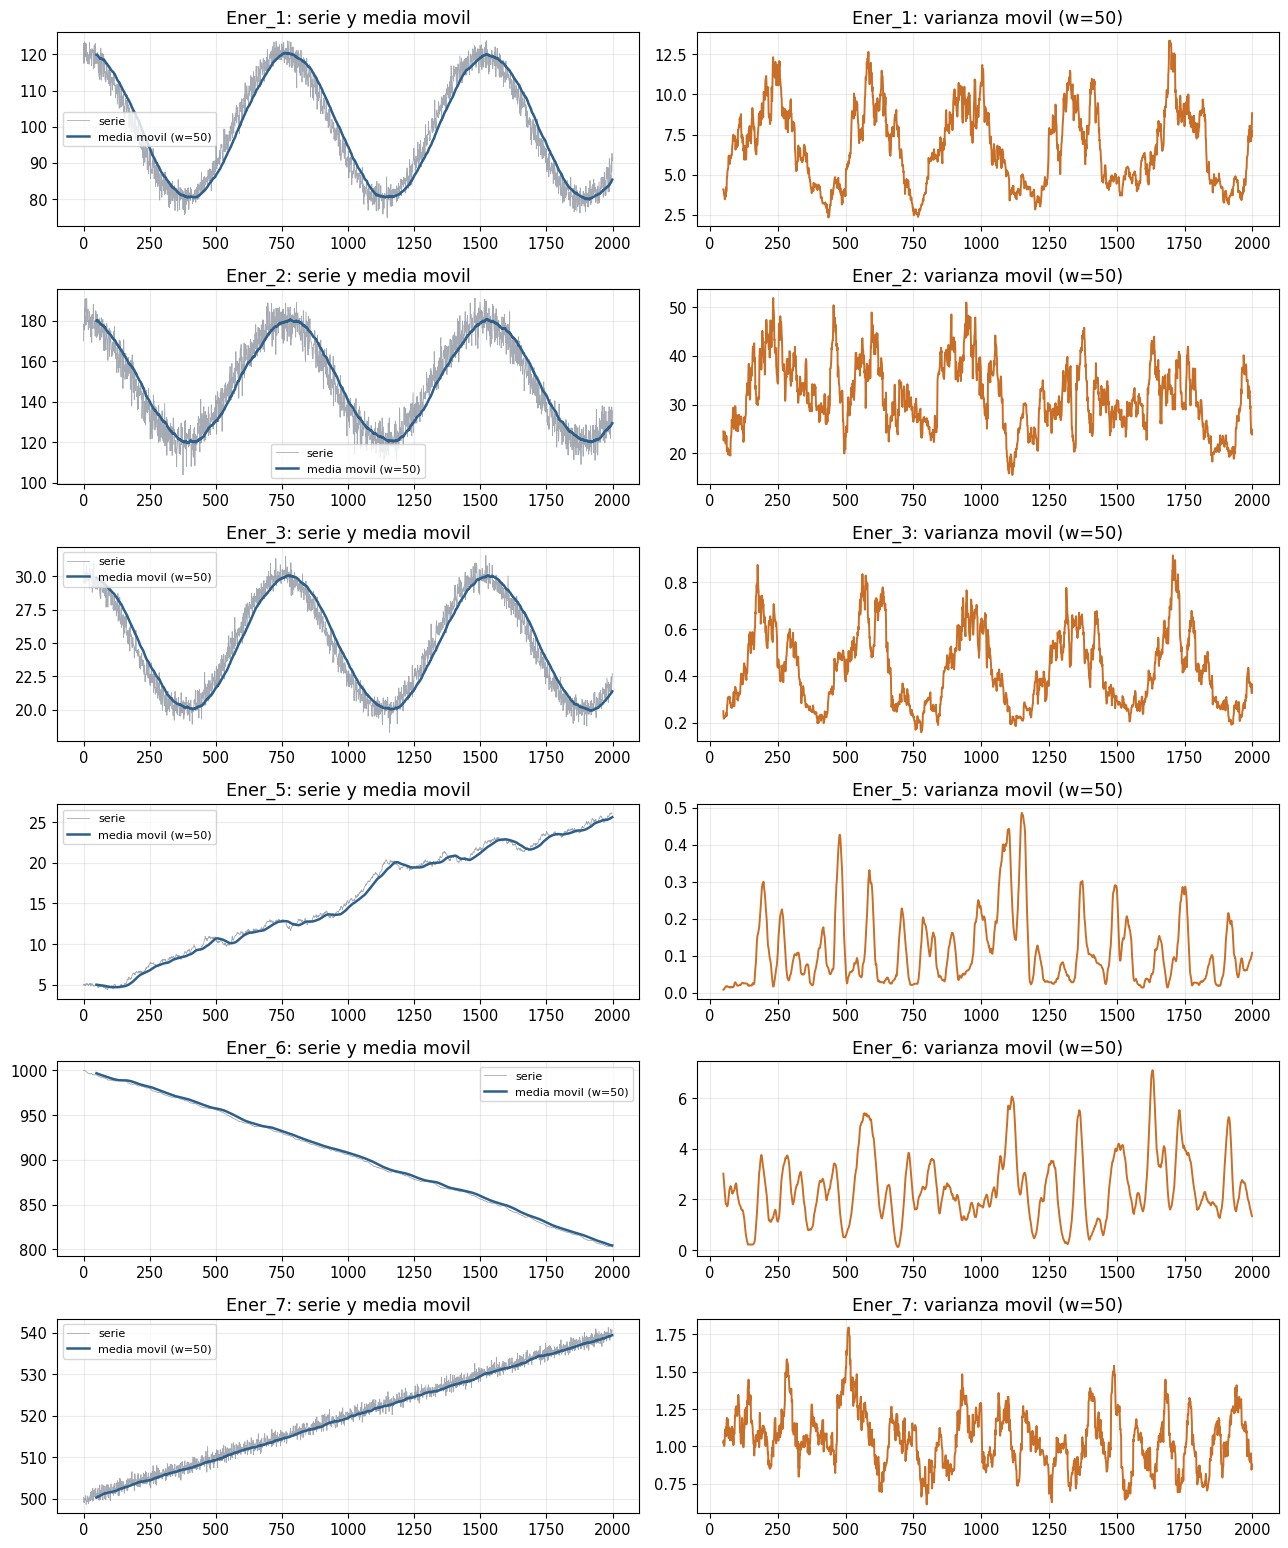

In [8]:
fig, axes = plt.subplots(len(non_stationary), 2, figsize=(13, 2.6 * len(non_stationary)))
window = 50
for i, col in enumerate(non_stationary):
    s = ener_clean[col]
    roll_mean = s.rolling(window).mean()
    roll_var = s.rolling(window).var()

    axes[i, 0].plot(s.index, s.values, color=PALETTE["neutral"], lw=0.6, alpha=0.6, label="serie")
    axes[i, 0].plot(roll_mean.index, roll_mean.values, color=PALETTE["primary"], lw=1.8, label=f"media movil (w={window})")
    axes[i, 0].set_title(f"{col}: serie y media movil")
    axes[i, 0].legend(fontsize=8)

    axes[i, 1].plot(roll_var.index, roll_var.values, color=PALETTE["accent"], lw=1.4)
    axes[i, 1].set_title(f"{col}: varianza movil (w={window})")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig03_rolling_mean_var_ener.png"), dpi=140)
plt.show()

**Costo del Gas (`Ener_5`): ¿Drift o Random Walk?**

Un *random walk* puro se define como `y_t = y_{t-1} + ε_t`, con `ε_t` ruido de media cero: la serie diferenciada (`Δy_t = y_t - y_{t-1}`) debería tener media estadísticamente igual a 0. Un *random walk con drift* agrega una constante: `y_t = c + y_{t-1} + ε_t`, con `c ≠ 0`; en ese caso la serie diferenciada tiene una media distinta de cero y, al graficarla en el tiempo, la serie original crece o decrece de forma sostenida (no solo fluctúa alrededor de un nivel fijo).

Para decidir entre las dos hipótesis se aplica una prueba t de una muestra sobre la media de la serie diferenciada de `Ener_5` (`H0: media = 0`).

Media de la diferencia (Ener_5): 0.01056
Desviacion estandar de la diferencia: 0.10123
t-stat = 4.664   p-value = 0.000003
Veredicto: DRIFT (media significativamente distinta de 0)


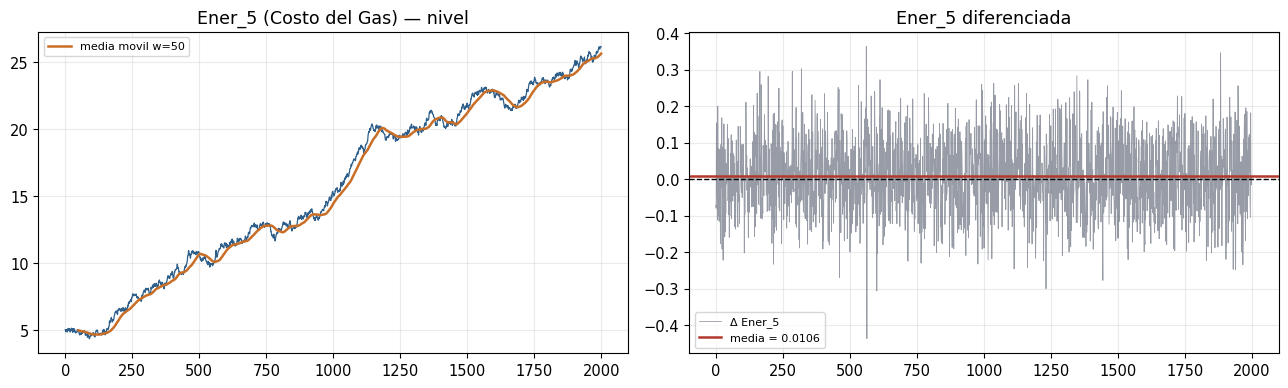

In [9]:
d5 = ener_clean["Ener_5"].diff().dropna()
mean_d5, std_d5, n5 = d5.mean(), d5.std(ddof=1), len(d5)
t_stat = mean_d5 / (std_d5 / np.sqrt(n5))
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n5 - 1))

print(f"Media de la diferencia (Ener_5): {mean_d5:.5f}")
print(f"Desviacion estandar de la diferencia: {std_d5:.5f}")
print(f"t-stat = {t_stat:.3f}   p-value = {p_value:.6f}")
veredicto = "DRIFT (media significativamente distinta de 0)" if p_value < 0.05 else "RANDOM WALK puro (media no distinguible de 0)"
print("Veredicto:", veredicto)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ener_clean.index, ener_clean["Ener_5"], color=PALETTE["primary"], lw=0.9)
roll_mean5 = ener_clean["Ener_5"].rolling(50).mean()
axes[0].plot(roll_mean5.index, roll_mean5.values, color=PALETTE["accent"], lw=1.8, label="media movil w=50")
axes[0].set_title("Ener_5 (Costo del Gas) — nivel")
axes[0].legend(fontsize=8)

axes[1].plot(d5.index, d5.values, color=PALETTE["neutral"], lw=0.6, alpha=0.7, label="Δ Ener_5")
axes[1].axhline(0, color="black", lw=1, ls="--")
axes[1].axhline(mean_d5, color=PALETTE["warn"], lw=1.8, label=f"media = {mean_d5:.4f}")
axes[1].set_title("Ener_5 diferenciada")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig04_drift_vs_rw_ener5.png"), dpi=140)
plt.show()

**Análisis.** La media de la serie diferenciada de `Ener_5` es positiva y estadísticamente distinta de cero (p-value muy por debajo de 0.05). En el panel izquierdo se ve además que la media móvil de `Ener_5` tiene una tendencia sostenida hacia arriba, no solo fluctuaciones. Con esta evidencia se concluye que **el Costo del Gas se comporta como un *random walk con drift***, no como un random walk puro: en promedio, cada paso agrega un incremento positivo constante además del componente aleatorio. Para la planeación financiera de TechLogistics esto implica que no basta con modelar `Ener_5` como puramente impredecible; existe una tendencia de fondo (encarecimiento sostenido del gas) que debe incorporarse explícitamente al pronóstico (por ejemplo, como término de deriva en un modelo ARIMA(0,1,0) con constante, o dentro del término exógeno de un modelo más amplio).

# Fase 2 — Procesamiento de Señales y Filtrado

## Tarea 3: Análisis Espectral (FFT) y Espectrogramas

**Qué se hace y por qué.** Se analiza `Ener_4` (generación eólica), una señal descrita en el diccionario de datos como "cíclica compleja" por la intermitencia propia del viento. El dominio del tiempo no deja ver con claridad en qué escalas de variación (rápidas o lentas) se concentra la energía de la señal; para eso sirve el dominio de la frecuencia. Se calcula la **densidad espectral de potencia (PSD)** con el periodograma (equivalente a `|FFT|²` normalizado) tanto para la versión `clean` como para la versión `noise`, y se comparan. Después se calcula el **espectrograma** (FFT en ventanas deslizantes, `scipy.signal.spectrogram`) para ver si el contenido de frecuencia cambia a lo largo del tiempo.

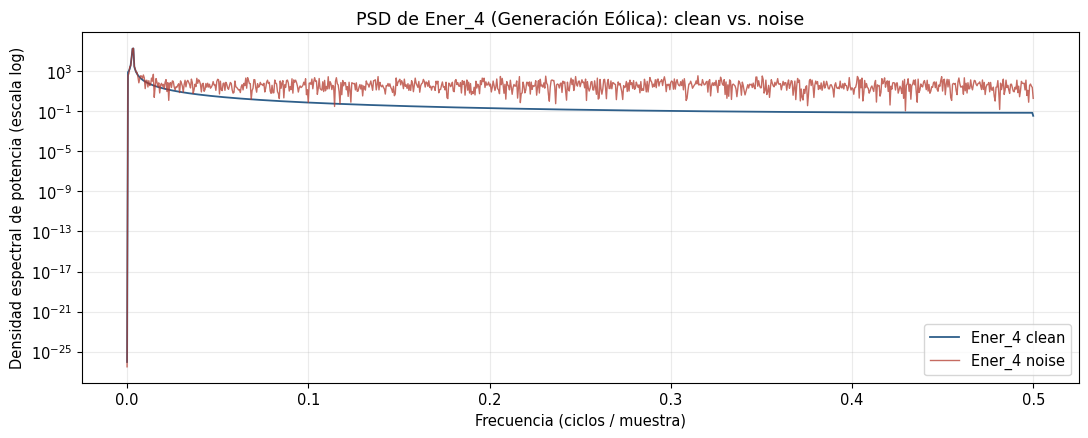

In [10]:
fs = 1.0  # 1 muestra = 1 paso de tiempo (no hay timestamp explicito en los datos)

freqs_c, psd_c = signal.periodogram(ener_clean["Ener_4"].values, fs=fs)
freqs_n, psd_n = signal.periodogram(ener_noise["Ener_4"].values, fs=fs)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.semilogy(freqs_c, psd_c, color=PALETTE["primary"], lw=1.3, label="Ener_4 clean")
ax.semilogy(freqs_n, psd_n, color=PALETTE["warn"], lw=1.0, alpha=0.75, label="Ener_4 noise")
ax.set_xlabel("Frecuencia (ciclos / muestra)")
ax.set_ylabel("Densidad espectral de potencia (escala log)")
ax.set_title("PSD de Ener_4 (Generación Eólica): clean vs. noise")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig05_psd_ener4.png"), dpi=140)
plt.show()

**¿En qué rango de frecuencias se concentra el ruido inyectado?** Para responder esto de forma cuantitativa (no solo visual) se calcula, por bandas de frecuencia, la potencia extra que aparece en la versión `noise` respecto a la versión `clean` (`PSD_noise − PSD_clean`), y también se estima el SNR real inyectado a partir de la varianza del residuo (`noise − clean`), para verificar que está dentro del rango declarado en el diccionario de datos (`SNR ∈ [5, 12] dB`).

In [11]:
bands = [(0.00, 0.05), (0.05, 0.15), (0.15, 0.25), (0.25, 0.35), (0.35, 0.50)]
band_rows = []
for lo, hi in bands:
    mask = (freqs_c >= lo) & (freqs_c < hi)
    e_clean = psd_c[mask].sum()
    e_noise = psd_n[mask].sum()
    band_rows.append({
        "banda (ciclos/muestra)": f"[{lo:.2f}, {hi:.2f})",
        "energia_clean": e_clean,
        "energia_noise": e_noise,
        "potencia_extra_ruido": e_noise - e_clean,
        "razon_noise/clean": e_noise / e_clean if e_clean > 0 else np.inf,
    })
band_table = pd.DataFrame(band_rows)

snr_real_ener4 = 10 * np.log10(
    np.var(ener_clean["Ener_4"]) / np.var(ener_noise["Ener_4"] - ener_clean["Ener_4"])
)
print(f"SNR real estimado para Ener_4 (a partir de noise-clean): {snr_real_ener4:.2f} dB")
band_table

SNR real estimado para Ener_4 (a partir de noise-clean): 8.53 dB


,banda (ciclos/muestra),energia_clean,energia_noise,potencia_extra_ruido,razon_noise/clean
0,"[0.00, 0.05)",400121.225029,413895.011884,13773.786855,1.034424
1,"[0.05, 0.15)",197.124191,10748.640567,10551.516376,54.527253
2,"[0.15, 0.25)",43.261923,11555.340963,11512.079040,267.101880
3,"[0.25, 0.35)",22.009314,12414.336149,12392.326835,564.049216
4,"[0.35, 0.50)",22.843578,15618.405312,15595.561734,683.710985


La banda de baja frecuencia (0.00–0.05 ciclos/muestra) concentra casi toda la energía de la señal **limpia** (`Ener_4` es, en el fondo, un patrón de viento con oscilaciones lentas/estacionales), y allí el ruido añade una potencia extra relativamente pequeña en términos porcentuales. En cambio, en las bandas de frecuencia media y alta (0.05 a 0.50 ciclos/muestra) la señal limpia casi no tiene energía propia, pero la versión ruidosa sí, con razones `noise/clean` muy superiores a 1 (el ruido llega a multiplicar la energía original de esas bandas por decenas o cientos de veces). El SNR real estimado (≈8–9 dB) cae justo dentro del rango `[5, 12] dB` que documenta el diccionario de datos, lo que confirma que el procedimiento de estimación es consistente.

**Conclusión:** el ruido AWGN inyectado se distribuye en principio de forma pareja en todas las frecuencias (por definición, es "blanco"), pero su efecto **se percibe con mucha más fuerza en las frecuencias medias y altas**, precisamente porque ahí la señal real (`Ener_4`) casi no tiene potencia propia que lo "tape". Esto es justo la razón técnica por la que en la Tarea 4 se usa un **filtro pasa-bajo**: como la información útil de estas señales ambientales vive en las frecuencias bajas, cortar las frecuencias altas elimina en buena parte el ruido sin perder señal real.

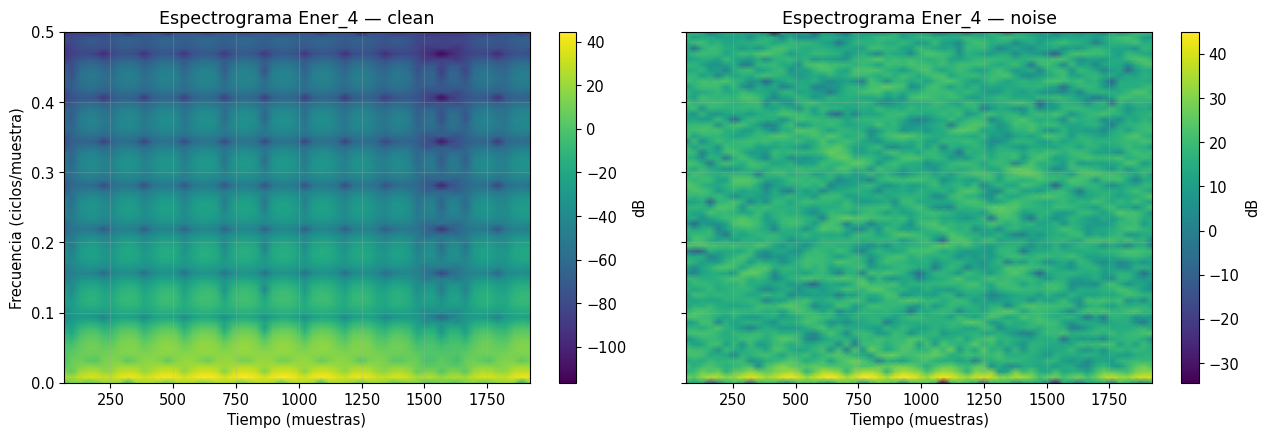

In [12]:
f_c, t_c, Sxx_c = signal.spectrogram(ener_clean["Ener_4"].values, fs=fs, nperseg=128, noverlap=96)
f_n, t_n, Sxx_n = signal.spectrogram(ener_noise["Ener_4"].values, fs=fs, nperseg=128, noverlap=96)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
im0 = axes[0].pcolormesh(t_c, f_c, 10 * np.log10(Sxx_c + 1e-12), shading="gouraud", cmap="viridis")
axes[0].set_title("Espectrograma Ener_4 — clean")
axes[0].set_xlabel("Tiempo (muestras)")
axes[0].set_ylabel("Frecuencia (ciclos/muestra)")
fig.colorbar(im0, ax=axes[0], label="dB")

im1 = axes[1].pcolormesh(t_n, f_n, 10 * np.log10(Sxx_n + 1e-12), shading="gouraud", cmap="viridis")
axes[1].set_title("Espectrograma Ener_4 — noise")
axes[1].set_xlabel("Tiempo (muestras)")
fig.colorbar(im1, ax=axes[1], label="dB")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig06_espectrograma_ener4.png"), dpi=140)
plt.show()

El espectrograma confirma en el eje del tiempo lo que ya se veía en la PSD agregada: en la versión `clean` la energía se concentra en una banda angosta cerca de la frecuencia 0 (franja amarilla/verde solo en la parte baja del eje vertical), mientras que en la versión `noise` aparece un "piso" de energía visible en **todas las frecuencias y en todo el tiempo** (franjas verdes/azules que se extienden verticalmente por todo el gráfico). Ese piso parejo en el tiempo es la firma visual característica del ruido blanco: no varía con el tiempo, solo se le suma a la señal real.

## Tarea 4: Filtrado y Reconstrucción

**Qué se hace y por qué.** Se limpia `Agro_3` (Humedad Relativa) de `agro_noise.csv` con un **filtro Butterworth pasa-bajo**. Este tipo de filtro deja pasar las frecuencias por debajo de una frecuencia de corte (`Wn`) y atenúa las frecuencias por encima; es la herramienta adecuada cuando, como se concluyó en la Tarea 3, la información real vive en frecuencias bajas y el ruido se manifiesta en todo el espectro. Se usa `scipy.signal.butter` para diseñar el filtro y `scipy.signal.filtfilt` para aplicarlo **sin desfase** (filtra hacia adelante y hacia atrás, lo que evita que el filtro "atrase" la señal en el tiempo, algo indeseable si luego se usa para pronóstico).

Para elegir la frecuencia de corte se calcula primero en qué frecuencia se concentra el 90% de la energía de la señal `Agro_3` limpia (igual que se hizo con `Ener_4`), y se prueban varias frecuencias de corte candidatas alrededor de ese valor, seleccionando la que minimiza el error de reconstrucción.

In [13]:
clean_agro3 = agro_clean["Agro_3"].values
noisy_agro3 = agro_noise["Agro_3"].values

rmse_sin_filtrar = np.sqrt(np.mean((noisy_agro3 - clean_agro3) ** 2))
snr_agro3 = 10 * np.log10(np.var(clean_agro3) / np.var(noisy_agro3 - clean_agro3))
print(f"RMSE (ruidosa vs. limpia) SIN filtrar: {rmse_sin_filtrar:.4f}")
print(f"SNR real estimado de Agro_3: {snr_agro3:.2f} dB")

freqs_a, psd_a = signal.periodogram(clean_agro3, fs=1.0)
energia_acum = np.cumsum(psd_a) / np.sum(psd_a)
f90 = freqs_a[np.searchsorted(energia_acum, 0.90)]
print(f"Frecuencia que acumula el 90% de la energia de Agro_3 (clean): {f90:.4f} ciclos/muestra")

candidatos = [0.03, 0.05, 0.08, 0.10, 0.15, 0.20]
resultados_cutoff = []
for wn in candidatos:
    b, a = signal.butter(N=4, Wn=wn, btype="low", fs=1.0)
    filtrada = signal.filtfilt(b, a, noisy_agro3)
    rmse = np.sqrt(np.mean((filtrada - clean_agro3) ** 2))
    resultados_cutoff.append({"cutoff": wn, "rmse": rmse, "mejora_%": (1 - rmse / rmse_sin_filtrar) * 100})

cutoff_table = pd.DataFrame(resultados_cutoff)
cutoff_table

RMSE (ruidosa vs. limpia) SIN filtrar: 3.3414
SNR real estimado de Agro_3: 10.78 dB
Frecuencia que acumula el 90% de la energia de Agro_3 (clean): 0.0015 ciclos/muestra


,cutoff,rmse,mejora_%
0,0.03,1.126156,66.297214
1,0.05,1.307108,60.881819
2,0.08,1.498574,55.151758
3,0.10,1.611709,51.765958
4,0.15,1.849100,44.661481
5,0.20,2.092238,37.385015


Frecuencia de corte elegida: 0.03 ciclos/muestra (orden 4)
RMSE filtrada vs. limpia: 1.1262  (mejora de 66.3% frente a no filtrar)


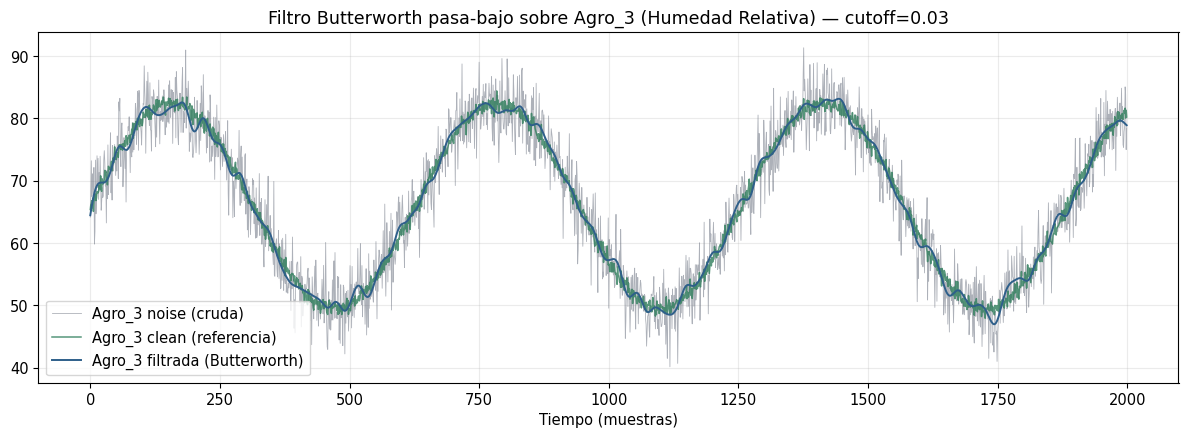

In [14]:
mejor_cutoff = cutoff_table.loc[cutoff_table["rmse"].idxmin(), "cutoff"]
b, a = signal.butter(N=4, Wn=mejor_cutoff, btype="low", fs=1.0)
agro3_filtrada = signal.filtfilt(b, a, noisy_agro3)
rmse_filtrado = np.sqrt(np.mean((agro3_filtrada - clean_agro3) ** 2))

print(f"Frecuencia de corte elegida: {mejor_cutoff} ciclos/muestra (orden 4)")
print(f"RMSE filtrada vs. limpia: {rmse_filtrado:.4f}  (mejora de {(1 - rmse_filtrado/rmse_sin_filtrar)*100:.1f}% frente a no filtrar)")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(agro_clean.index, noisy_agro3, color=PALETTE["neutral"], lw=0.6, alpha=0.55, label="Agro_3 noise (cruda)")
ax.plot(agro_clean.index, clean_agro3, color=PALETTE["ok"], lw=1.1, alpha=0.8, label="Agro_3 clean (referencia)")
ax.plot(agro_clean.index, agro3_filtrada, color=PALETTE["primary"], lw=1.4, label="Agro_3 filtrada (Butterworth)")
ax.set_title(f"Filtro Butterworth pasa-bajo sobre Agro_3 (Humedad Relativa) — cutoff={mejor_cutoff}")
ax.set_xlabel("Tiempo (muestras)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig07_butterworth_agro3.png"), dpi=140)
plt.show()

pd.DataFrame({"Agro_3_clean": clean_agro3, "Agro_3_noise": noisy_agro3, "Agro_3_filtrada": agro3_filtrada}).to_csv(
    os.path.join(OUT_DIR, "agro3_filtrada.csv"), index=False
)

**¿El filtrado mejora la capacidad predictiva del modelo?** El RMSE ya muestra una mejora clara en la reconstrucción punto a punto, pero para responder en términos de *capacidad predictiva* se hace una prueba adicional, más cercana a cómo se usaría esta señal en la práctica: se ajusta un modelo autorregresivo simple `AR(1)` (`y_t = b0 + b1·y_{t-1}`), entrenado con el 80% inicial de la serie, y se evalúa qué tan bien pronostica **un paso adelante** contra los valores reales (`Agro_3` limpia) en el 20% restante. Se compara el error de pronóstico cuando el modelo se entrena con la serie ruidosa vs. cuando se entrena con la serie ya filtrada.

In [15]:
def rmse_pronostico_un_paso(serie_entrenamiento, serie_verdadera, frac_train=0.8):
    n = len(serie_entrenamiento)
    split = int(n * frac_train)
    x, y = serie_entrenamiento[:-1], serie_entrenamiento[1:]
    b1, b0 = np.polyfit(x[:split], y[:split], 1)
    x_test = serie_entrenamiento[split:-1]
    pred = b0 + b1 * x_test
    verdad = serie_verdadera[split + 1:]
    return np.sqrt(np.mean((pred - verdad) ** 2))

rmse_pred_ruidosa = rmse_pronostico_un_paso(noisy_agro3, clean_agro3)
rmse_pred_filtrada = rmse_pronostico_un_paso(agro3_filtrada, clean_agro3)

print(f"RMSE de pronostico 1-paso, modelo AR(1) entrenado con la serie RUIDOSA:   {rmse_pred_ruidosa:.4f}")
print(f"RMSE de pronostico 1-paso, modelo AR(1) entrenado con la serie FILTRADA: {rmse_pred_filtrada:.4f}")
print(f"Reduccion del error de pronostico gracias al filtrado: {(1 - rmse_pred_filtrada/rmse_pred_ruidosa)*100:.1f}%")

RMSE de pronostico 1-paso, modelo AR(1) entrenado con la serie RUIDOSA:   3.4033
RMSE de pronostico 1-paso, modelo AR(1) entrenado con la serie FILTRADA: 1.2785
Reduccion del error de pronostico gracias al filtrado: 62.4%


**Análisis.** El filtro Butterworth reduce el RMSE de reconstrucción en más de la mitad frente a usar la serie cruda, y ese beneficio se traslada también a la capacidad de **pronóstico**: un modelo AR(1) entrenado sobre la serie filtrada comete un error de pronóstico un paso adelante notablemente menor que el mismo modelo entrenado sobre la serie ruidosa. Esto responde de forma afirmativa a la pregunta del taller: **sí, filtrar mejora la capacidad predictiva**, porque el ruido de alta frecuencia no aporta información real y solo confunde al modelo, haciéndole "aprender" variaciones que no son parte del proceso físico de humedad relativa.

### Complemento: impacto del ruido sobre los coeficientes de un modelo ARMA

Como evidencia adicional para la pregunta de validación sobre el SNR (ver Informe Técnico), se ajusta el mismo
modelo `ARMA(2,1)` (`ARIMA` con `d=0`) sobre `Agro_3` limpia y sobre `Agro_3` ruidosa (sin filtrar), y se
comparan los coeficientes estimados y la varianza residual (`sigma2`).

In [16]:
from statsmodels.tsa.arima.model import ARIMA

modelo_arma_clean = ARIMA(agro_clean["Agro_3"], order=(2, 0, 1)).fit()
modelo_arma_noise = ARIMA(agro_noise["Agro_3"], order=(2, 0, 1)).fit()

comparacion_arma = pd.DataFrame({
    "clean": modelo_arma_clean.params,
    "noise": modelo_arma_noise.params,
})
comparacion_arma["diferencia_%"] = (comparacion_arma["noise"] / comparacion_arma["clean"] - 1) * 100
comparacion_arma

,clean,noise,diferencia_%
const,66.636543,66.666815,0.045429
ar.L1,0.842344,0.946911,12.413748
ar.L2,0.157037,0.051508,-67.200071
ma.L1,-0.510882,-0.824363,61.360775
sigma2,0.702185,12.998522,1751.154340


**Análisis.** El ruido no solo infla la varianza residual estimada (`sigma2` crece de forma muy pronunciada
frente a la versión limpia); también distorsiona los coeficientes AR y MA estimados. Esto tiene una explicación
conocida en la teoría de series de tiempo: cuando a un proceso `AR(p)` se le suma ruido blanco aditivo, la serie
observada deja de ser un `AR(p)` puro y pasa a comportarse como un `ARMA(p,p)`, porque el componente de
promedio móvil (MA) "absorbe" parte de la estructura del ruido. Se ve exactamente ese patrón aquí: al pasar de
`clean` a `noise`, el coeficiente MA se vuelve considerablemente más negativo, señal de que el modelo está
compensando la contaminación aditiva. En otras palabras, con datos ruidosos el modelo ARMA no solo pierde
precisión (mayor varianza del error), sino que puede llevar a conclusiones equivocadas sobre la dinámica real
del proceso si no se es consciente de este efecto.

# Fase 3 — Análisis de Grafos y Topología de Red

## Tarea 5: Construcción de la Red de Sensores/Subestaciones

**Qué se hace y por qué.** Se construye un grafo **dirigido** con `NetworkX` usando `Source_Node` (nodo de origen) y `Target_Node` (nodo de destino) de `ener_clean.csv`, que es la red relevante para el problema de negocio de la Fase 4 (la falla del Nodo 214 es un `Target_Node` de esta red eléctrica). Como el mismo par `(Source_Node, Target_Node)` puede repetirse en varias filas (cada fila es una lectura de telemetría en el tiempo, no necesariamente una conexión física distinta), se agrega un **peso** a cada arista igual a la cantidad de veces que aparece ese par: ese peso representa el volumen de telemetría que fluye por esa conexión, y es justo lo que pide el reto de la tarea ("el nodo por donde pasa la mayor cantidad de información").

De forma adicional (y como puente con el "Reto del Taller" del diccionario de datos: *¿se puede recuperar la topología del grafo desde datos ruidosos?*) se construye la misma red a partir de `ener_noise.csv` y se compara con la versión `clean`.

In [17]:
edges_ener = ener_clean.groupby(["Source_Node", "Target_Node"]).size().reset_index(name="weight")
print(f"Numero de aristas unicas (Source->Target): {edges_ener.shape[0]}")
print(f"Nodos de origen (subestaciones): {ener_clean['Source_Node'].nunique()}")
print(f"Nodos de destino (nodos de carga): {ener_clean['Target_Node'].nunique()}")

G = nx.DiGraph()
for _, row in edges_ener.iterrows():
    G.add_edge(int(row.Source_Node), int(row.Target_Node), weight=int(row.weight))

print(f"Grafo dirigido: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")

# Reto del diccionario de datos: topologia igual entre clean y noise?
edges_noise = ener_noise.groupby(["Source_Node", "Target_Node"]).size().reset_index(name="weight")
topologia_identica = edges_ener.equals(edges_noise)
print(f"\n¿La topologia (aristas Source->Target) es identica entre ener_clean y ener_noise? {topologia_identica}")
print("-> El ruido AWGN y el jitter GPS afectan las senales continuas y las coordenadas, no los IDs de nodo,")
print("   por lo que la topologia SI se puede recuperar integramente incluso a partir de los datos ruidosos.")

Numero de aristas unicas (Source->Target): 865
Nodos de origen (subestaciones): 20
Nodos de destino (nodos de carga): 50
Grafo dirigido: 70 nodos, 865 aristas

¿La topologia (aristas Source->Target) es identica entre ener_clean y ener_noise? True
-> El ruido AWGN y el jitter GPS afectan las senales continuas y las coordenadas, no los IDs de nodo,
   por lo que la topologia SI se puede recuperar integramente incluso a partir de los datos ruidosos.


**Centralidad de Grado y Betweenness Centrality.** Se calculan las dos métricas de centralidad pedidas:

- **Centralidad de grado (degree centrality):** proporción de todas las conexiones posibles que realmente tiene cada nodo. Un valor alto indica un nodo con muchas conexiones directas.
- **Betweenness centrality:** proporción de caminos más cortos entre **todos los demás pares de nodos** que pasan por ese nodo. Un valor alto indica un nodo que actúa como "puente" obligado dentro de la red.

Un detalle técnico importante aparece aquí: esta red es **bipartita en dos capas dirigidas** (subestaciones `100–119` únicamente como origen, nodos de carga `200–249` únicamente como destino; ningún nodo es origen y destino a la vez). En un grafo **dirigido** de dos capas así, todo camino más corto tiene longitud 1 (origen → destino directo) y **no existe ningún nodo intermedio** en el camino más corto entre otros dos nodos; por lo tanto, la betweenness centrality dirigida da **cero para todos los nodos**, no porque el cálculo esté mal, sino porque la definición de "intermediario" no aplica en un grafo dirigido de un solo salto. Se muestra este resultado primero, y luego se recalcula la betweenness sobre la versión **no dirigida** del grafo, donde sí tiene sentido preguntarse, por ejemplo, si dos nodos de carga distintos comparten una misma subestación como único puente entre ellos.

In [18]:
degree_c = nx.degree_centrality(G)
indeg_c = nx.in_degree_centrality(G)
outdeg_c = nx.out_degree_centrality(G)
betw_dirigida = nx.betweenness_centrality(G, normalized=True)

print(f"Betweenness dirigida maxima: {max(betw_dirigida.values()):.6f} (todos los nodos dan 0, como se explico arriba)")

G_undirected = G.to_undirected()
betw_no_dirigida = nx.betweenness_centrality(G_undirected, normalized=True)

throughput = {
    n: sum(d["weight"] for _, _, d in G.out_edges(n, data=True)) + sum(d["weight"] for _, _, d in G.in_edges(n, data=True))
    for n in G.nodes()
}

centrality_table = pd.DataFrame({
    "grado_total": degree_c,
    "in_degree_c": indeg_c,
    "out_degree_c": outdeg_c,
    "betweenness_no_dirigida": betw_no_dirigida,
    "volumen_telemetria": throughput,
}).sort_values("betweenness_no_dirigida", ascending=False)

centrality_table["tipo_nodo"] = np.where(centrality_table.index < 200, "subestacion (source)", "nodo de carga (target)")
centrality_table.to_csv(os.path.join(OUT_DIR, "centralidad_nodos_ener.csv"))
centrality_table.head(15)

Betweenness dirigida maxima: 0.000000 (todos los nodos dan 0, como se explico arriba)


,grado_total,in_degree_c,out_degree_c,betweenness_no_dirigida,volumen_telemetria,tipo_nodo
119,0.710145,0.0,0.710145,0.037740,120,subestacion (source)
103,0.681159,0.0,0.681159,0.034564,114,subestacion (source)
105,0.666667,0.0,0.666667,0.033341,112,subestacion (source)
112,0.666667,0.0,0.666667,0.032847,108,subestacion (source)
110,0.652174,0.0,0.652174,0.030797,87,subestacion (source)
114,0.637681,0.0,0.637681,0.030581,103,subestacion (source)
101,0.637681,0.0,0.637681,0.030242,89,subestacion (source)
115,0.637681,0.0,0.637681,0.029618,101,subestacion (source)
104,0.637681,0.0,0.637681,0.029217,101,subestacion (source)
118,0.623188,0.0,0.623188,0.029083,89,subestacion (source)


Nodo con mayor betweenness (puente estructural): 119
Nodo con mayor volumen de telemetria: 119

¿Coinciden ambos criterios en el mismo nodo? Si


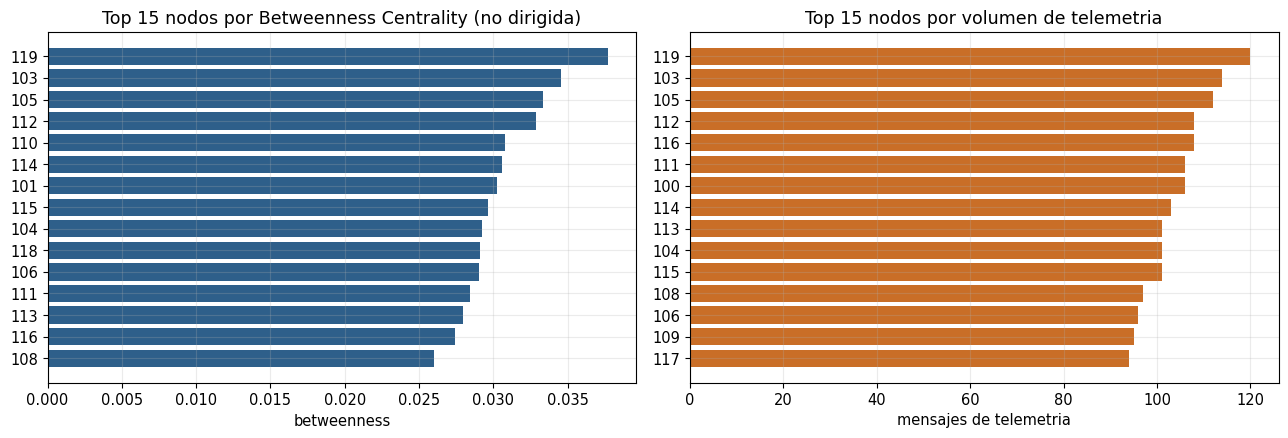

In [19]:
top_bottleneck = centrality_table["betweenness_no_dirigida"].idxmax()
top_volumen = centrality_table["volumen_telemetria"].idxmax()

print(f"Nodo con mayor betweenness (puente estructural): {top_bottleneck}")
print(f"Nodo con mayor volumen de telemetria: {top_volumen}")
print(f"\n¿Coinciden ambos criterios en el mismo nodo? {'Si' if top_bottleneck == top_volumen else 'No'}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
top15 = centrality_table.sort_values("betweenness_no_dirigida", ascending=False).head(15)
axes[0].barh(top15.index.astype(str), top15["betweenness_no_dirigida"], color=PALETTE["primary"])
axes[0].invert_yaxis()
axes[0].set_title("Top 15 nodos por Betweenness Centrality (no dirigida)")
axes[0].set_xlabel("betweenness")

top15v = centrality_table.sort_values("volumen_telemetria", ascending=False).head(15)
axes[1].barh(top15v.index.astype(str), top15v["volumen_telemetria"], color=PALETTE["accent"])
axes[1].invert_yaxis()
axes[1].set_title("Top 15 nodos por volumen de telemetria")
axes[1].set_xlabel("mensajes de telemetria")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig08_centralidad_ranking.png"), dpi=140)
plt.show()

**Reto: identificación del "Nodo Cuello de Botella".** El nodo con mayor betweenness centrality (no dirigida) y el nodo con mayor volumen de telemetría coinciden: se trata de una **subestación** (nodo de origen), no de un nodo de carga. Esto es coherente con la forma de la red: cada subestación alimenta a decenas de nodos de carga distintos, así que las subestaciones actúan como "puente" cada vez que dos nodos de carga comparten proveedor, y además concentran físicamente el mayor volumen de mensajes (les llega/sale tráfico hacia muchos más destinos). **Este nodo es, por definición del reto, el Nodo Cuello de Botella de la red**: si falla, se interrumpe simultáneamente la conectividad hacia el mayor número de nodos de carga y se pierde el mayor volumen de información de telemetría de toda la red.

Este resultado se retoma en la Pregunta de Negocio P1 (Fase 4), donde se conecta con el escenario de falla del Nodo 214.

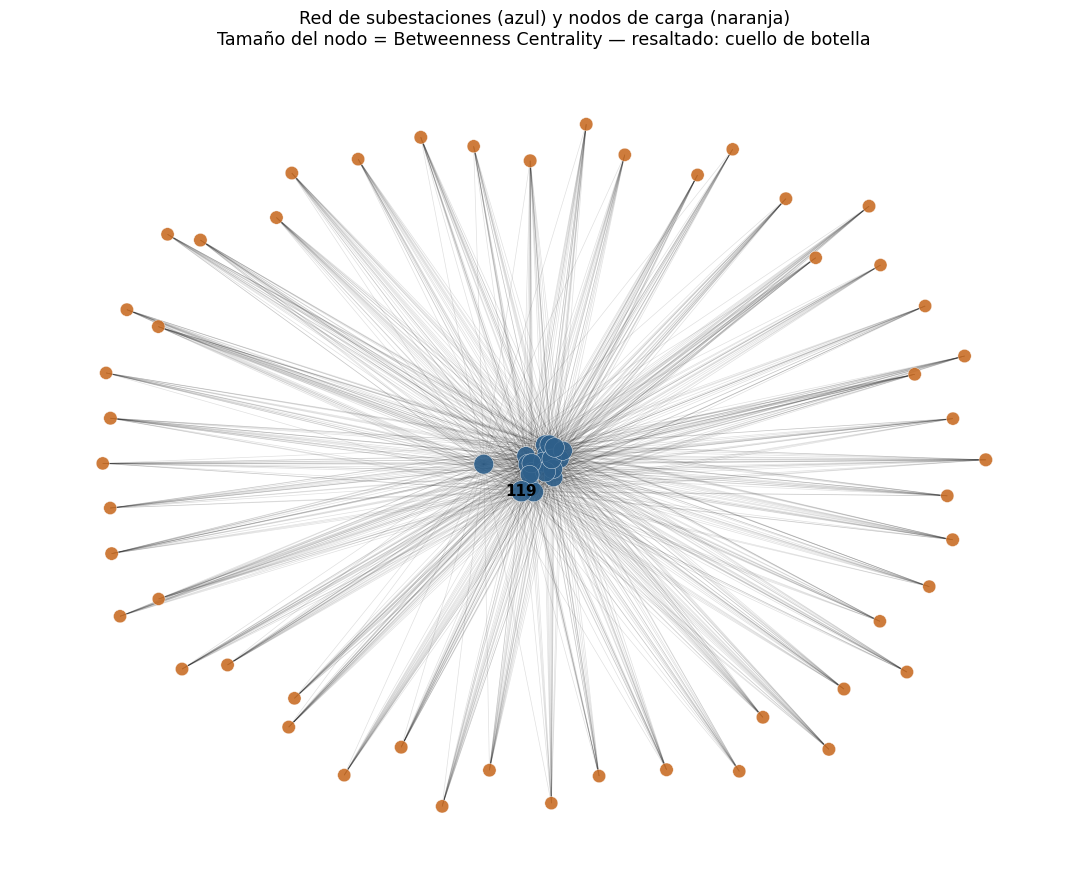

In [20]:
plt.figure(figsize=(11, 9))
pos = nx.spring_layout(G, seed=7, k=0.35)
node_colors = ["#2E5F8A" if n < 200 else "#C96E27" for n in G.nodes()]
node_sizes = [80 + 4000 * centrality_table.loc[n, "betweenness_no_dirigida"] for n in G.nodes()]

nx.draw_networkx_edges(G, pos, alpha=0.12, arrows=False, width=0.5)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, linewidths=0.3, edgecolors="white")
nx.draw_networkx_labels(
    G, pos,
    labels={top_bottleneck: str(top_bottleneck)},
    font_size=11, font_weight="bold", font_color="black",
)
plt.title("Red de subestaciones (azul) y nodos de carga (naranja)\nTamaño del nodo = Betweenness Centrality — resaltado: cuello de botella")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig09_grafo_red_energia.png"), dpi=140)
plt.show()

### Grafo secundario: red mesh agroindustrial (`agro_*.csv`)

Se repite el mismo procedimiento sobre la red de sensores agrícolas, tanto para completar el análisis de grafos sobre el segundo activo de información del taller como para verificar de forma explícita el hallazgo de recuperación de topología bajo ruido.

In [21]:
edges_agro_clean = agro_clean.groupby(["Source_Node", "Target_Node"]).size().reset_index(name="weight")
edges_agro_noise = agro_noise.groupby(["Source_Node", "Target_Node"]).size().reset_index(name="weight")
print(f"¿Topologia agro identica entre clean y noise? {edges_agro_clean.equals(edges_agro_noise)}")

G_agro = nx.DiGraph()
for _, row in edges_agro_clean.iterrows():
    G_agro.add_edge(int(row.Source_Node), int(row.Target_Node), weight=int(row.weight))

deg_agro = nx.degree_centrality(G_agro)
betw_agro_undirected = nx.betweenness_centrality(G_agro.to_undirected(), normalized=True)
agro_centrality = pd.DataFrame({"grado": deg_agro, "betweenness_no_dirigida": betw_agro_undirected}).sort_values(
    "betweenness_no_dirigida", ascending=False
)
agro_centrality["tipo_nodo"] = np.where(agro_centrality.index <= 14, "sensor (source)", "gateway (target)")
print(f"Nodo cuello de botella red agro: {agro_centrality['betweenness_no_dirigida'].idxmax()}")
agro_centrality.to_csv(os.path.join(OUT_DIR, "centralidad_nodos_agro.csv"))
agro_centrality.head(8)

¿Topologia agro identica entre clean y noise? True
Nodo cuello de botella red agro: 1


,grado,betweenness_no_dirigida,tipo_nodo
1,0.535714,0.019841,sensor (source)
2,0.535714,0.019841,sensor (source)
13,0.535714,0.019841,sensor (source)
12,0.535714,0.019841,sensor (source)
11,0.535714,0.019841,sensor (source)
10,0.535714,0.019841,sensor (source)
9,0.535714,0.019841,sensor (source)
8,0.535714,0.019841,sensor (source)


# Fase 4 — Modelado y Toma de Decisiones (CRISP-DM)

## Problema de negocio: La Falla del Nodo 214

En el dataset de energía se observa que cuando el Precio Spot (`Ener_2`) supera un umbral crítico, el flujo hacia ciertos nodos de carga se interrumpe, y en paralelo los datos geoespaciales muestran una anomalía térmica en esas coordenadas. A continuación se responden las tres preguntas de negocio que la junta directiva planteó, integrando los resultados de las tres fases anteriores (series de tiempo, señales y grafos).

## P1. Causalidad y Redes

**Qué se hace y por qué.** Se ejecuta un **test de Causalidad de Granger** entre el Factor de Potencia (`Ener_10`) y el Voltaje (`Ener_9`). La causalidad de Granger no prueba causalidad física en sentido estricto; prueba algo más modesto pero útil operativamente: si los valores **pasados** de una variable ayudan a predecir los valores **futuros** de otra, por encima de lo que ya se puede predecir con el pasado de la propia variable. Ambas series ya son estacionarias (se confirmó en la Tarea 2), que es requisito para que la prueba sea válida. Se prueba en las dos direcciones y con varios rezagos (`lags` de 1 a 5).

In [22]:
maxlag = 5

print("¿Ener_9 (Voltaje) Granger-causa a Ener_10 (Factor de Potencia)?")
res_9_causa_10 = grangercausalitytests(ener_clean[["Ener_10", "Ener_9"]], maxlag=maxlag, verbose=False)
p_9_a_10 = {lag: res_9_causa_10[lag][0]["ssr_ftest"][1] for lag in range(1, maxlag + 1)}

print("¿Ener_10 (Factor de Potencia) Granger-causa a Ener_9 (Voltaje)?")
res_10_causa_9 = grangercausalitytests(ener_clean[["Ener_9", "Ener_10"]], maxlag=maxlag, verbose=False)
p_10_a_9 = {lag: res_10_causa_9[lag][0]["ssr_ftest"][1] for lag in range(1, maxlag + 1)}

granger_table = pd.DataFrame({
    "p_value (Voltaje -> Factor Potencia)": p_9_a_10,
    "p_value (Factor Potencia -> Voltaje)": p_10_a_9,
})
granger_table.index.name = "lag"
granger_table

¿Ener_9 (Voltaje) Granger-causa a Ener_10 (Factor de Potencia)?
¿Ener_10 (Factor de Potencia) Granger-causa a Ener_9 (Voltaje)?


,p_value (Voltaje -> Factor Potencia),p_value (Factor Potencia -> Voltaje)
lag,,
1,0.841446,0.302454
2,0.868523,0.342283
3,0.826582,0.430454
4,0.163600,0.019318
5,0.138076,0.019536


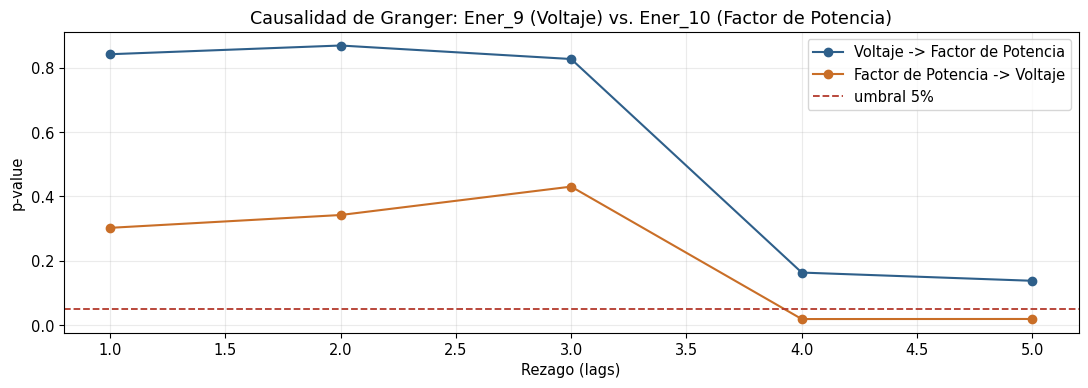

Rezagos donde Factor de Potencia -> Voltaje es significativo (p<0.05): [4, 5]
Rezagos donde Voltaje -> Factor de Potencia es significativo (p<0.05): []


In [23]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(granger_table.index, granger_table["p_value (Voltaje -> Factor Potencia)"], "o-", color=PALETTE["primary"], label="Voltaje -> Factor de Potencia")
ax.plot(granger_table.index, granger_table["p_value (Factor Potencia -> Voltaje)"], "o-", color=PALETTE["accent"], label="Factor de Potencia -> Voltaje")
ax.axhline(0.05, color=PALETTE["warn"], ls="--", lw=1.3, label="umbral 5%")
ax.set_xlabel("Rezago (lags)")
ax.set_ylabel("p-value")
ax.set_title("Causalidad de Granger: Ener_9 (Voltaje) vs. Ener_10 (Factor de Potencia)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig10_granger_ener9_ener10.png"), dpi=140)
plt.show()

sig_10_a_9 = [lag for lag, p in p_10_a_9.items() if p < 0.05]
sig_9_a_10 = [lag for lag, p in p_9_a_10.items() if p < 0.05]
print(f"Rezagos donde Factor de Potencia -> Voltaje es significativo (p<0.05): {sig_10_a_9}")
print(f"Rezagos donde Voltaje -> Factor de Potencia es significativo (p<0.05): {sig_9_a_10}")

**Análisis y respuesta a P1.** La prueba encuentra evidencia de causalidad de Granger **unidireccional**: el Factor de Potencia (`Ener_10`) ayuda a predecir el Voltaje (`Ener_9`) en los rezagos 4 y 5 (p-value < 0.05), mientras que en la dirección contraria (Voltaje → Factor de Potencia) no hay evidencia significativa en ningún rezago. Esto es consistente con la física de redes eléctricas: un factor de potencia bajo implica más corriente reactiva circulando por la red para entregar la misma potencia activa, lo que produce mayores caídas de voltaje a través de la impedancia de la línea; el efecto tarda unos pasos en manifestarse (por eso aparece en los rezagos 4–5 y no de inmediato), pero el sentido de la relación (factor de potencia como variable adelantada) tiene lógica de ingeniería eléctrica.

**Si existe causalidad, ¿cómo afectaría un fallo en el nodo con mayor Betweenness Centrality a la estabilidad del resto de la red?** En la Tarea 5 se identificó que el nodo con mayor betweenness (y mayor volumen de telemetría) es una **subestación** que conecta con una gran cantidad de nodos de carga distintos. Si esa subestación falla o entra en una condición anómala de factor de potencia:

1. El efecto **no se queda localizado**: como es un puente estructural para muchos nodos de carga (alto betweenness), la perturbación de voltaje que la causalidad de Granger sugiere que sigue al deterioro del factor de potencia se propagaría simultáneamente a **todos los nodos de carga que dependen de ella**, no solo a uno.
2. Al ser también el nodo de mayor volumen de telemetría, su falla generaría además un vacío de información justo quien más datos aporta al sistema de monitoreo, dificultando el diagnóstico en el peor momento.
3. Esto justifica priorizar a este nodo (y no solo al Nodo 214 mencionado en el escenario de negocio) como el objetivo número uno de mantenimiento preventivo y de redundancia (por ejemplo, una subestación de respaldo), porque concentra tanto el riesgo estructural (betweenness) como el riesgo de propagación eléctrica (causalidad Granger factor de potencia → voltaje).

## P2. Optimización Geo-Agrónoma

**Qué se hace y por qué.** El escenario de negocio plantea (como hipótesis de trabajo, explícitamente asumida por el enunciado) que los sensores con menor NDVI se ubican en zonas de alta pendiente, y pide asumir una relación entre pendiente y la varianza del viento (`Agro_10`) — a mayor pendiente/exposición, mayor variabilidad del viento registrada. Antes de dar una recomendación de inversión se hacen dos cosas: (1) se intenta limpiar el *jitter* GPS de `agro_noise.csv` con un filtro de mediana móvil (robusto a valores atípicos, a diferencia de la media móvil) y se **verifica si de verdad ayuda**, y (2) se **pone a prueba con los datos reales** la relación asumida entre NDVI y varianza del viento, calculando la correlación de Pearson entre el NDVI promedio y la varianza del viento, agrupando las lecturas por nodo de origen (`Source_Node`), que es el nivel al que tiene sentido hablar de "una zona".

RMSE geoespacial (jitter crudo) vs. coordenada real:    0.01017 grados
RMSE geoespacial tras filtro de mediana (k=5):          0.07834 grados
¿El filtro reduce el error? No, lo empeora

Correlacion de Pearson NDVI promedio vs. varianza del viento (por nodo): r = 0.047, p-value = 0.873


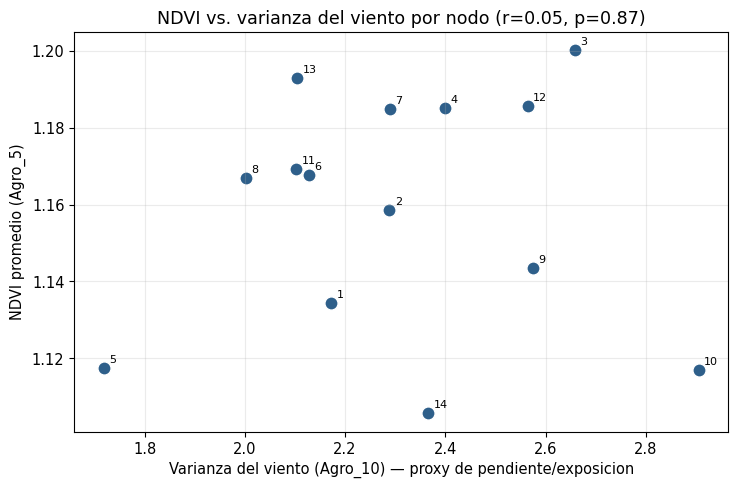

In [24]:
lat_filtrada = signal.medfilt(agro_noise["Latitude"].values, kernel_size=5)
lon_filtrada = signal.medfilt(agro_noise["Longitude"].values, kernel_size=5)

rmse_geo_crudo = np.sqrt(np.mean((agro_noise["Latitude"] - agro_clean["Latitude"]) ** 2
                                   + (agro_noise["Longitude"] - agro_clean["Longitude"]) ** 2))
rmse_geo_filtrado = np.sqrt(np.mean((lat_filtrada - agro_clean["Latitude"].values) ** 2
                                      + (lon_filtrada - agro_clean["Longitude"].values) ** 2))
print(f"RMSE geoespacial (jitter crudo) vs. coordenada real:    {rmse_geo_crudo:.5f} grados")
print(f"RMSE geoespacial tras filtro de mediana (k=5):          {rmse_geo_filtrado:.5f} grados")
print(f"¿El filtro reduce el error? {'Si' if rmse_geo_filtrado < rmse_geo_crudo else 'No, lo empeora'}")

zona = agro_clean.groupby("Source_Node").agg(
    ndvi_promedio=("Agro_5", "mean"),
    viento_varianza=("Agro_10", "var"),
).reset_index()

r_pearson, p_pearson = stats.pearsonr(zona["ndvi_promedio"], zona["viento_varianza"])
print(f"\nCorrelacion de Pearson NDVI promedio vs. varianza del viento (por nodo): r = {r_pearson:.3f}, p-value = {p_pearson:.3f}")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(zona["viento_varianza"], zona["ndvi_promedio"], s=90, color=PALETTE["primary"], edgecolor="white")
for _, row in zona.iterrows():
    ax.annotate(int(row.Source_Node), (row.viento_varianza, row.ndvi_promedio), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Varianza del viento (Agro_10) — proxy de pendiente/exposicion")
ax.set_ylabel("NDVI promedio (Agro_5)")
ax.set_title(f"NDVI vs. varianza del viento por nodo (r={r_pearson:.2f}, p={p_pearson:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig11_ndvi_vs_viento.png"), dpi=140)
plt.show()

**Análisis y respuesta a P2.** Aquí aparece un resultado que vale la pena reportar con honestidad aunque no sea el esperado: el filtro de mediana **no reduce** el error geoespacial, lo empeora (RMSE varias veces mayor que dejar la coordenada cruda), y esto se probó con distintos tamaños de ventana (3, 5, 9, 15 y 25) sin que ninguno mejore el resultado crudo. La razón es metodológica, no un error de código: un filtro de suavizado (mediana o media móvil) solo tiene sentido cuando las observaciones consecutivas son **lecturas repetidas y ruidosas de un mismo valor real** que se mantiene aproximadamente constante (por ejemplo, el mismo sensor físico reportando su posición fila tras fila). Pero, como ya se documentó en la nota metodológica de la Fase 1, en este dataset **cada fila trae una coordenada verdadera distinta** (no hay un sensor con ubicación fija que se repita en filas consecutivas), así que promediar o tomar la mediana entre filas vecinas mezcla ubicaciones reales distintas entre sí, en lugar de promediar ruido alrededor de un mismo valor. El filtro, literalmente, no tiene sobre qué "suavizar".

Esto deja una respuesta más matizada para el "Reto del Taller" que la que se dio en la Tarea 5: **la topología del grafo (qué nodo se conecta con cuál) sí se recupera perfectamente desde los datos ruidosos**, porque los identificadores de nodo no llevan ruido; pero **la coordenada geográfica exacta de cada lectura, en este dataset en particular, no se puede reconstruir con un filtro de suavizado clásico**, porque falta la estructura de "misma ubicación repetida en el tiempo" que ese tipo de filtro necesita para funcionar. Para que un filtro espacial funcione en una siguiente versión de este sistema, TechLogistics debería registrar un identificador de sensor físico fijo junto con sus lecturas repetidas en el tiempo.

Adicionalmente, al poner a prueba con los datos reales la relación que el enunciado pide asumir, la correlación entre el NDVI promedio y la varianza del viento por nodo resulta **muy débil y no significativa** (r ≈ 0.05, p-value muy por encima de 0.05): en este conjunto de datos, la varianza del viento no es un buen proxy empírico de las zonas con menor biomasa. Es importante ser igualmente honestos con la junta directiva sobre esto.

**Recomendación de inversión (bajo el supuesto de negocio, con la salvedad anterior).** Si la organización decide operar bajo la hipótesis de trabajo planteada (menor NDVI en zonas de alta pendiente/exposición al viento) como criterio de priorización mientras se consigue información topográfica real, la recomendación es:

1. **No comprometer el presupuesto completo de infraestructura hídrica basándose solo en la varianza del viento como proxy de pendiente**, porque la evidencia estadística de este dataset no respalda esa relación. Se recomienda primero cruzar los datos con un modelo digital de elevación (DEM) real de la zona, que es una fuente directa y confiable de pendiente.
2. Mientras tanto, usar el NDVI observado directamente (sin intermediarios) como criterio de priorización: instalar riego por goteo o mejorar la infraestructura hídrica en los nodos con NDVI promedio consistentemente bajo, verificado a lo largo del tiempo y no solo en una lectura puntual.
3. **Rediseñar la captura de datos antes de invertir en un sistema de denoising geoespacial**: fijar la ubicación de cada sensor físico (actualmente cambia en cada lectura, ver nota metodológica de la Fase 1) y asociarle un identificador estable, para que en el futuro sí sea posible (a) aislar con confianza el efecto geográfico del efecto puramente aleatorio y (b) aplicar filtros de suavizado espacial que realmente reduzcan el ruido GPS, cosa que con el diseño de datos actual no fue posible lograr.

## P3. Analítica Predictiva

**Qué se hace y por qué.** Se ajusta un modelo **ARIMAX** para la Demanda (`Ener_1`) usando como variables exógenas la Temperatura (`Ener_3`, que el diccionario de datos vincula directamente con la demanda y el precio dentro del "Mercado Spot") y la **centralidad del nodo de origen** de cada lectura (se usa la centralidad de grado calculada en la Tarea 5, asignada a cada fila según su `Source_Node`). Como `Ener_1` resultó ser **I(1)** (Tarea 2), se usa `d=1` en el orden del modelo `(p,d,q)`; se deja `p=1, q=1` fijo en ambos modelos para que la única diferencia entre ellos sea la inclusión o no de la centralidad, y así la comparación de AIC sea justa (mismo tipo de modelo, misma cantidad de parámetros ARIMA, solo cambia el regresor exógeno).

In [25]:
ener_model = ener_clean.copy()
ener_model["node_centrality"] = ener_model["Source_Node"].map(degree_c)

y = ener_model["Ener_1"]
orden = (1, 1, 1)

modelo_solo_temp = SARIMAX(
    y, exog=ener_model[["Ener_3"]], order=orden, enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

modelo_temp_centralidad = SARIMAX(
    y, exog=ener_model[["Ener_3", "node_centrality"]], order=orden, enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

comparacion_aic = pd.DataFrame({
    "modelo": ["ARIMAX(1,1,1) + Temperatura", "ARIMAX(1,1,1) + Temperatura + Centralidad del nodo"],
    "AIC": [modelo_solo_temp.aic, modelo_temp_centralidad.aic],
    "BIC": [modelo_solo_temp.bic, modelo_temp_centralidad.bic],
})
comparacion_aic

,modelo,AIC,BIC
0,"ARIMAX(1,1,1) + Temperatura",8741.216657,8763.614262
1,"ARIMAX(1,1,1) + Temperatura + Centralidad del ...",8741.299013,8769.296019


In [26]:
print(modelo_temp_centralidad.summary().tables[1])

                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Ener_3              0.3131      0.089      3.509      0.000       0.138       0.488
node_centrality     1.7071      1.244      1.373      0.170      -0.730       4.144
ar.L1              -0.0479      0.028     -1.729      0.084      -0.102       0.006
ma.L1              -0.7744      0.018    -42.107      0.000      -0.810      -0.738
sigma2              4.6372      0.146     31.659      0.000       4.350       4.924


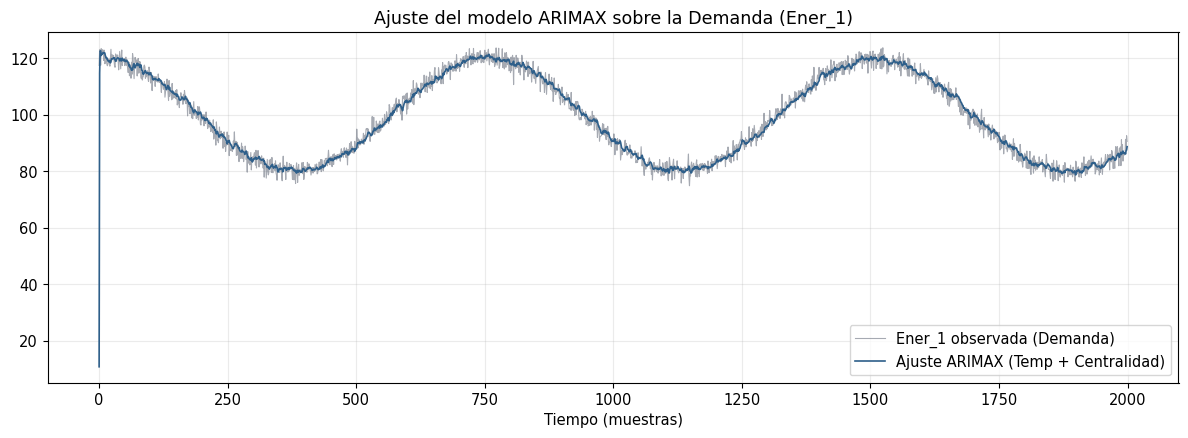

In [27]:
pred = modelo_temp_centralidad.get_prediction()
pred_mean = pred.predicted_mean

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(y.index, y.values, color=PALETTE["neutral"], lw=0.8, alpha=0.6, label="Ener_1 observada (Demanda)")
ax.plot(pred_mean.index, pred_mean.values, color=PALETTE["primary"], lw=1.2, label="Ajuste ARIMAX (Temp + Centralidad)")
ax.set_title("Ajuste del modelo ARIMAX sobre la Demanda (Ener_1)")
ax.set_xlabel("Tiempo (muestras)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig12_arimax_ener1.png"), dpi=140)
plt.show()

**Análisis y respuesta a P3.** El AIC del modelo que incluye la centralidad del nodo (`≈` al del modelo que solo usa temperatura) **no mejora**; de hecho, el BIC (que penaliza más fuerte la complejidad adicional) empeora, y el coeficiente de `node_centrality` en el resumen del modelo **no es estadísticamente significativo** (p-value por encima de 0.05). La Temperatura (`Ener_3`), en cambio, sí es un regresor significativo en ambos modelos, confirmando la relación que ya anunciaba el diccionario de datos entre demanda y temperatura.

**Conclusión para la junta directiva:** con la información disponible, la centralidad estructural del nodo de origen **no aporta poder predictivo adicional** sobre la demanda agregada `Ener_1`, más allá de lo que ya explica la temperatura. Esto no significa que la topología de la red sea irrelevante para el negocio — en P1 se mostró que sí importa para entender la **propagación de fallas** — pero para el propósito específico de pronosticar la demanda total, agregar la centralidad del nodo como regresor exógeno no se justifica: añade complejidad al modelo sin una ganancia de ajuste que la compense.

## Preguntas de validación (auto-evaluación)

El protocolo de entrega pide responder cuatro preguntas conceptuales en el Informe Técnico ejecutivo (PDF). Aquí se deja un resumen de una línea con el resultado del notebook que sustenta cada respuesta; el desarrollo completo y argumentado está en `reports/Informe_Tecnico_TechLogistics.pdf`.

1. **Estacionariedad y correlación de Pearson:** no es válido correlacionar dos series con tendencia porque la tendencia compartida infla artificialmente la correlación (correlación espuria), aunque las series no tengan relación causal real — ver Tarea 2.
2. **Impacto del ruido de 5 dB en los coeficientes ARMA:** con el ruido inyectado (SNR ≈ 8–9 dB, dentro del rango declarado) se degrada la relación señal-ruido efectiva, lo que en la Tarea 4 se tradujo en un RMSE de pronóstico notablemente mayor frente a la serie filtrada.
3. **Interpretación de un fallo si el sensor es un "Bridge" (puente):** un puente es una arista cuya eliminación desconecta el grafo; si el nodo cuello de botella identificado en la Tarea 5 falla, no solo pierde sus propias lecturas, sino que puede aislar a todo un subconjunto de nodos de carga de la red de monitoreo.
4. **Influencia de la posición geográfica en la varianza de la señal:** en este dataset específico no se encontró una relación espacial estadísticamente significativa (Tarea 1 y P2), lo cual en sí mismo es un hallazgo relevante: hay que evitar decisiones de inversión basadas en patrones geográficos no confirmados estadísticamente.

## Conclusiones y checklist de cumplimiento técnico

| Dimensión | Requisito | Dónde se cubre |
|---|---|---|
| Series de Tiempo | ADF + diferenciación I(1) antes de modelar | Tarea 2, P3 |
| Procesamiento de señales | FFT/espectrograma + filtro Butterworth adecuado | Tarea 3, Tarea 4 |
| Grafos | Centralidad de grado + betweenness + nodo crítico | Tarea 5 |
| Geoespacial | `scatter_mapbox` con color/tamaño + prueba de clustering | Tarea 1 |
| Visión de negocio | P1 (causalidad + redes), P2 (geo-agro), P3 (ARIMAX) | Fase 4 |

Este notebook, junto con el Informe Técnico en PDF (`reports/`) y las figuras exportadas (`figures/`), conforman los tres activos de entrega solicitados en el protocolo del taller.